A notebook to look at bombcell parameters for manually curated sessions

In [9]:
%reload_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from behave_analysis.process.process import Process
from behave_analysis.postprocess.bc_process.bombcell_utils import get_params, get_metric_info_dict_JR
from behave_analysis.database.Experiments.JAL004_ex import JAL4_flip4_3Sept, JAL4_flip5_11Sept, JAL4_flip6_19Sept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip5_25mar, JAL6_flip6_28mar
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip4_10may, JAL8_shelt_22apr
experiments_objects = [JAL8_flip4_10may, JAL8_shelt_22apr, JAL6_flip5_25mar, JAL6_flip6_28mar, JAL4_flip4_3Sept, JAL4_flip5_11Sept, JAL4_flip6_19Sept]

In [3]:
hist_dict = {}

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"] # list of 6 distinct hex colors
mouse_id = ["JAL003", "JAL004","JAL005","JAL006","JAL007","JAL008"]
metrics = {"nPeaks": 1,
        "nTroughs": 1,
        "waveformBaselineFlatness": .02,
        "waveformDuration_peakTrough": 50,
        "scndPeakToTroughRatio": .02,
        "spatialDecaySlope": .002,
        "peak1ToPeak2Ratio": 5,
        "mainPeakToTroughRatio": .1,
        "rawAmplitude": 15,
        "signalToNoiseRatio": 5,
        "fractionRPVs_estimatedTauR": .05,
        # "nSpikes": 10000,
        "presenceRatio": .01,
        "percentageSpikesMissing_gaussian": 1}

labels = ["mua", "good", "noise"]

for exp in experiments_objects:
    session = Process(exp).load_session()
    session_folder = os.path.join(session.base_path, session.file_path)
    import re
    m = re.search(r"(\d{4})_?(\d{2})_?(\d{2})T(\d{2})_?(\d{2})_?(\d{2})$", session.file_path)
    date = f"{m.group(1)}_{m.group(2)}_{m.group(3)}"
    name = f"{session.mouse}_{session.experiment}_{date}"
    for d in os.listdir(session_folder):
        if os.path.isdir(os.path.join(session_folder, d)) and d.endswith("_g0"):
            imec_folder = os.path.join(session_folder, d, d + "_imec0")
            ks_dir = os.path.join(imec_folder, "SI_KS_output", "sorter_output")
            df = pd.read_csv(os.path.join(ks_dir, f"cluster_rawAmplitude.tsv"), sep="\t")
            phy_df = pd.read_csv(os.path.join(ks_dir, "cluster_group.tsv"), sep="\t") # os.path.join(ks_dir, "cluster_KSlabels.tsv")
            if np.amax(df["cluster_id"].to_numpy().astype(int)) != np.amax(phy_df["cluster_id"].to_numpy().astype(int)):
                print(f"Cluster IDs do not match for {name}. Skipping.")
                continue
            print(f"Processing {name}...")
            hist_dict[name] = {}
            for label in labels:
                hist_dict[name][label] = {}
            for metric in metrics.keys():
                df = pd.read_csv(os.path.join(ks_dir, f"cluster_{metric}.tsv"), sep="\t")
                for label in labels:
                    ids = phy_df[phy_df["group"] == label]["cluster_id"].to_numpy().astype(int)
                    # find all the rows in df that have cluster_id in ids
                    df_filtered = df[df["cluster_id"].isin(ids)]
                    data = df_filtered[metric].to_numpy()
                    h = np.histogram(data, bins=np.arange(np.nanmin(data)-metrics[metric], np.nanmax(data)+metrics[metric], metrics[metric]))
                    hist_dict[name][label][metric] = h[0]/np.sum(~np.isnan(data))
                    hist_dict[name][label][metric+"_bins"] = h[1][:-1]

Processing JAL008_flip_2024_05_10...
Processing JAL008_shelt_2024_04_22...
Processing JAL006_flip_2024_03_25...
Processing JAL006_flip_2024_03_28...
Processing JAL004_flip_2023_09_03...
Processing JAL004_flip_2023_09_11...
Processing JAL004_flip_2023_09_19...


In [4]:
"""Load in parmas and quality metrics for one session"""
raw_file = os.path.join(imec_folder, d + "_t0.imec0.ap.bin")
meta_file = os.path.join(imec_folder, d + "_t0.imec0.ap.meta")
param = get_params(ks_dir, raw_file, meta_file, session.mouse)

In [11]:
%pip install ipympl
%matplotlib widget

Making overview plot...


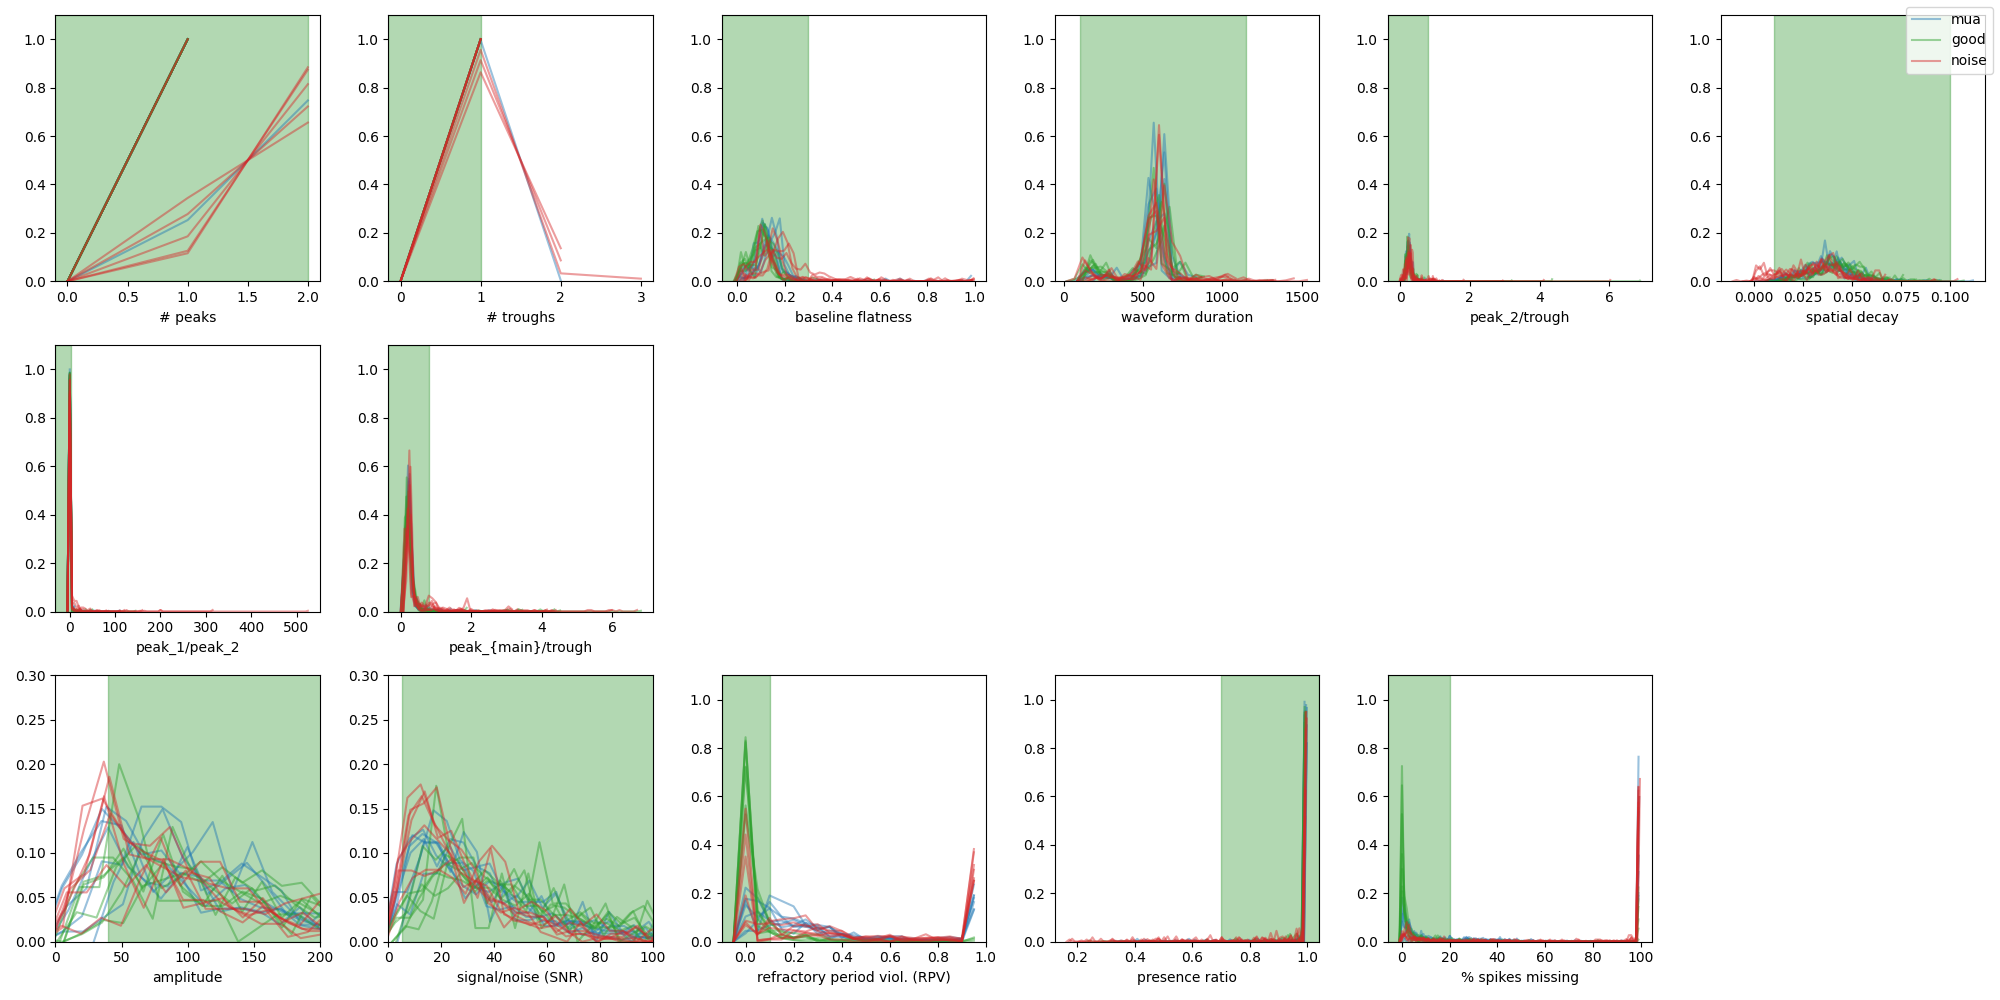

In [14]:
"""Make overview plot"""
print("Making overview plot...")
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(3, 6)
noise_col, mua_col, non_somatic_col = 0, 0, 0
metric_info = get_metric_info_dict_JR(param)

# fixed colors per label across all sessions
label_colors = {
    "mua": "#1f77b4",
    "good": "#2ca02c",
    "noise": "#d62728",
}

for i, metric in enumerate(metrics.keys()):
    vmi = metric_info[metric]
    if vmi.metric_type == "nonsomatic":
        row = 1
        ax = fig.add_subplot(gs[row, non_somatic_col])
        non_somatic_col += 1
    elif vmi.metric_type == "noise":
        row = 0
        ax = fig.add_subplot(gs[row, noise_col])
        noise_col += 1
    elif vmi.metric_type == "mua":
        row = 2
        ax = fig.add_subplot(gs[row, mua_col])
        mua_col += 1

    # plot each session for each label; same color for same label
    for label in labels:
        for session in hist_dict.keys():
            y = hist_dict[session][label][metric]
            x = hist_dict[session][label][metric + "_bins"]

            # one legend entry per label
            add_label = label if session == list(hist_dict.keys())[0] else None
            ax.plot(x, y, color=label_colors[label], alpha=0.45, lw=1.5, label=add_label)

    ax.set_xlabel(vmi.short_name)
    patchx = np.array(ax.get_xlim())
    if vmi.min_threshold is not None:
        patchx[0] = vmi.min_threshold
    if vmi.max_threshold is not None:
        patchx[1] = vmi.max_threshold
    patch = plt.Rectangle((patchx[0], 0), patchx[1] - patchx[0], 1.1, color="green", alpha=0.3)
    ax.add_patch(patch)
    ax.set_ylim(0, 1.1)
    if metric == "rawAmplitude":
        ax.set_xlim(0, 200)
        ax.set_ylim(0, 0.3)
    if metric == "signalToNoiseRatio":
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 0.3)

handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right")
plt.tight_layout()

fig.savefig("Z:/Jasmine_Laurence/bombcell/bc_after_phy_qm_overview_plot.png")